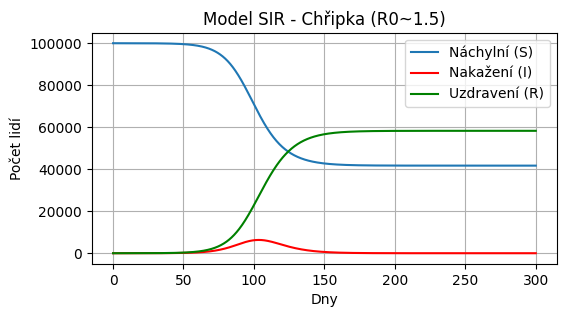

--- Chřipka (R0~1.5) ---
1. Vrchol epidemie: den 103
2. Trvání epidemie (pod 1 nakaženého): 236 dnů
3. Nakonec onemocní cca 58.3% lidí.


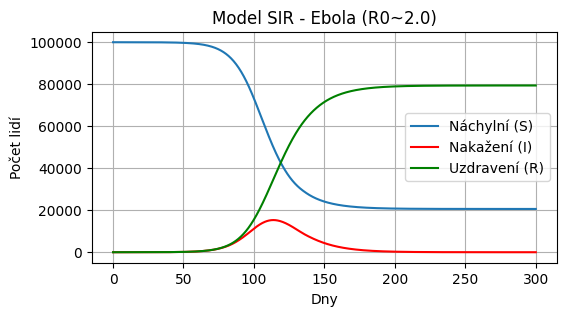

--- Ebola (R0~2.0) ---
1. Vrchol epidemie: den 114
2. Trvání epidemie (pod 1 nakaženého): 295 dnů
3. Nakonec onemocní cca 79.4% lidí.


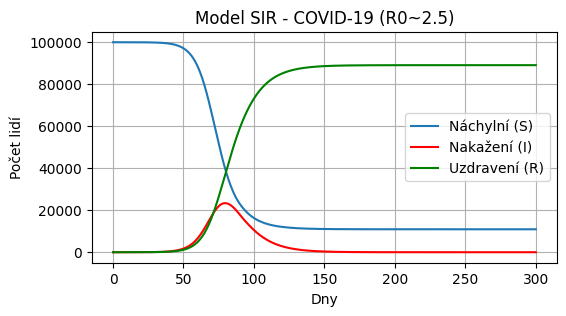

--- COVID-19 (R0~2.5) ---
1. Vrchol epidemie: den 80
2. Trvání epidemie (pod 1 nakaženého): 230 dnů
3. Nakonec onemocní cca 89.1% lidí.


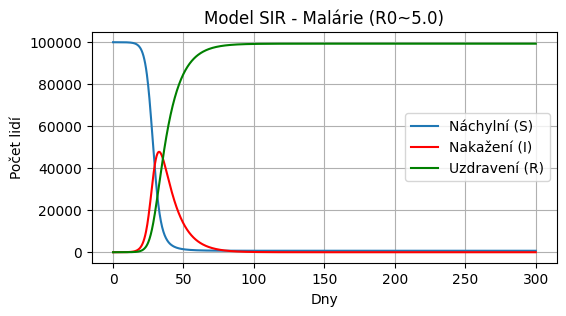

--- Malárie (R0~5.0) ---
1. Vrchol epidemie: den 33
2. Trvání epidemie (pod 1 nakaženého): 149 dnů
3. Nakonec onemocní cca 99.3% lidí.


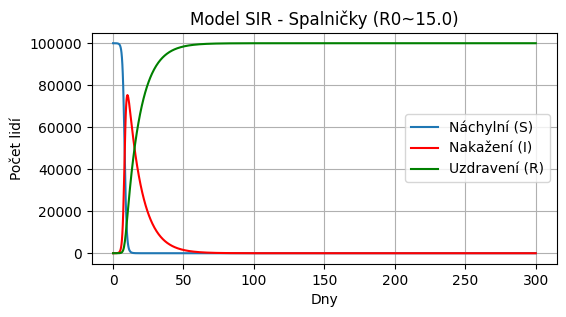

--- Spalničky (R0~15.0) ---
1. Vrchol epidemie: den 10
2. Trvání epidemie (pod 1 nakaženého): 124 dnů
3. Nakonec onemocní cca 100.0% lidí.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# SIR model s konstantní incidencí
def sir_model(t, y, N, beta, gamma):
    S, I, R = y
    dS_dt = -beta * S * I / N
    dI_dt = beta * S * I / N - gamma * I
    dR_dt = gamma * I
    return [dS_dt, dI_dt, dR_dt]

N = 100000
I0, R0_init = 1, 0
S0 = N - I0 - R0_init

diseases = {
    "Chřipka (R0~1.5)": (0.3, 0.2),
    "Ebola (R0~2.0)": (0.2, 0.1),
    "COVID-19 (R0~2.5)": (0.25, 0.1),
    "Malárie (R0~5.0)": (0.5, 0.1),
    "Spalničky (R0~15.0)": (1.5, 0.1)
}

t_span = (0, 300)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

for name, (beta, gamma) in diseases.items():
    sol = solve_ivp(sir_model, t_span, [S0, I0, R0_init], t_eval=t_eval, args=(N, beta, gamma))

    S, I, R = sol.y
    peak_day = sol.t[np.argmax(I)]
    end_day = sol.t[np.where(I < 1)[0][0]] if np.any(I < 1) else 300
    total_infected = R[-1] / N * 100

    plt.figure(figsize=(6, 3))
    plt.plot(sol.t, S, label='Náchylní (S)')
    plt.plot(sol.t, I, label='Nakažení (I)', color='red')
    plt.plot(sol.t, R, label='Uzdravení (R)', color='green')
    plt.title(f'Model SIR - {name}')
    plt.xlabel('Dny')
    plt.ylabel('Počet lidí')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"--- {name} ---")
    print(f"1. Vrchol epidemie: den {peak_day:.0f}")
    print(f"2. Trvání epidemie (pod 1 nakaženého): {end_day:.0f} dnů")
    print(f"3. Nakonec onemocní cca {total_infected:.1f}% lidí.")